
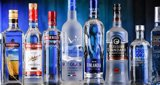
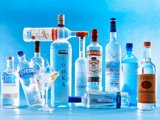
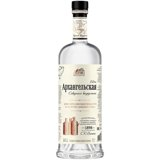
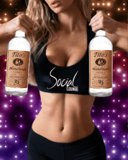
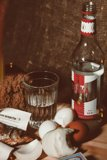
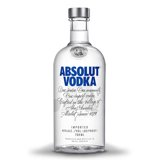
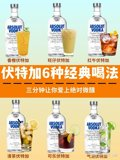
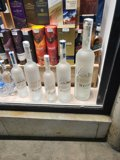
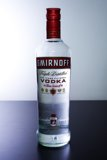
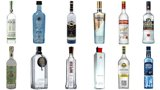
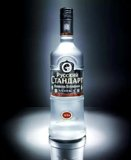
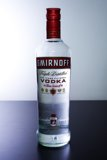
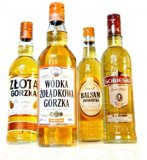
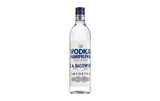
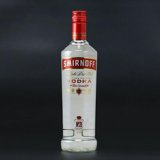
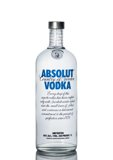
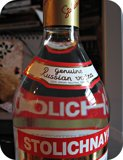
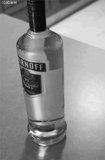
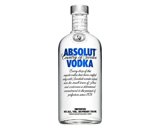
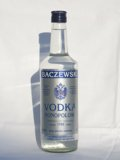
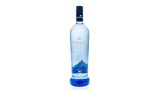
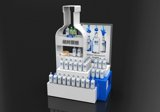
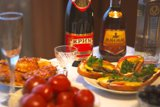
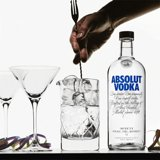
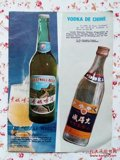
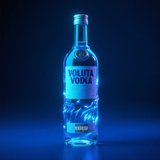
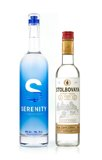
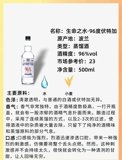
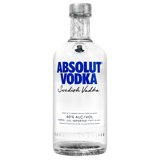
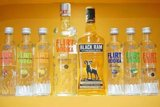
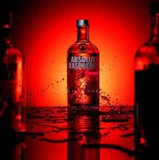
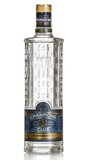
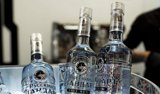
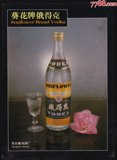
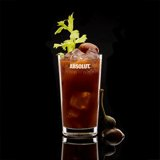
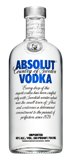
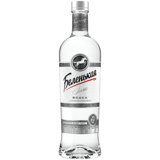
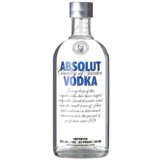
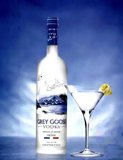
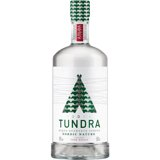
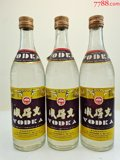
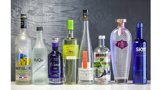
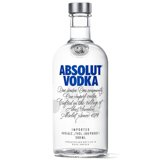
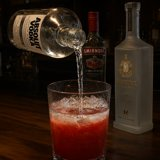


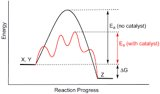
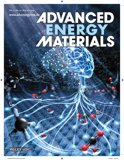
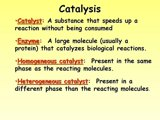
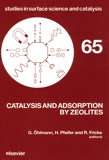
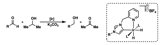
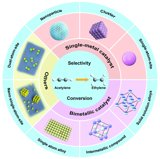
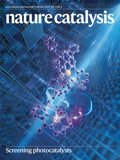
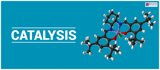
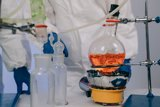
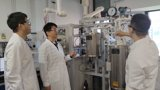
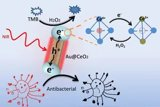
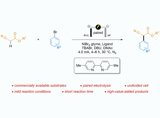
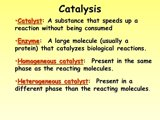
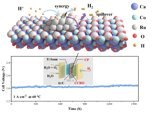
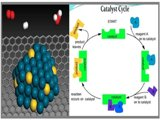
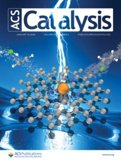
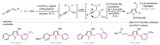
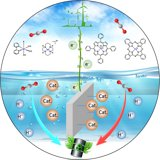
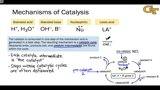
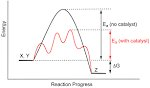
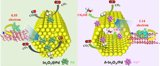
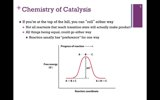
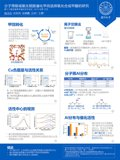
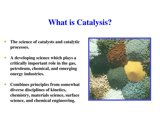
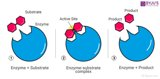
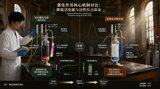
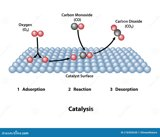
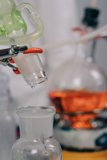
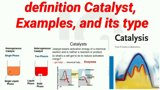
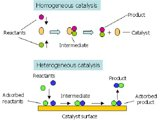
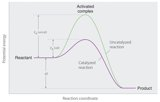
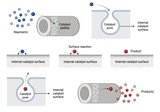
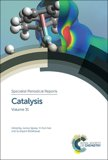
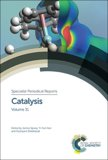
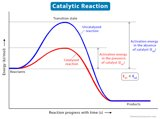
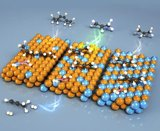
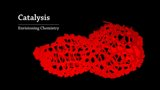
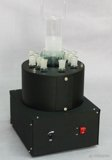


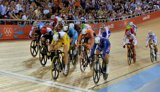
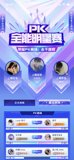
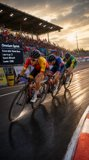


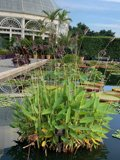
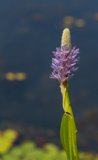
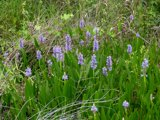
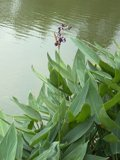
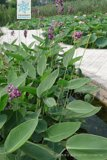
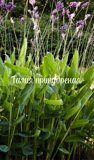
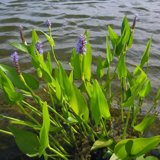
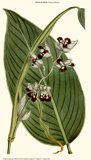
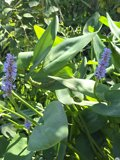
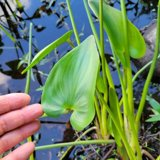


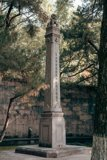
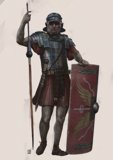
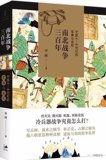
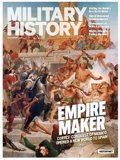
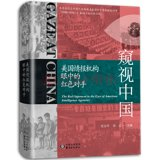
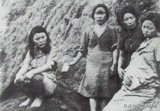
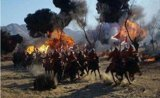
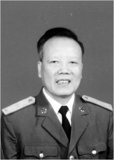
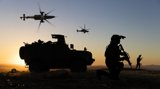
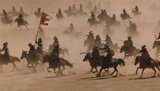
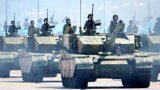
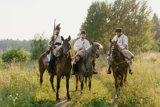
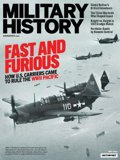
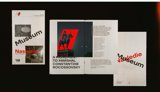
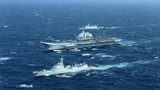
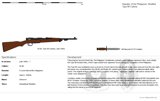
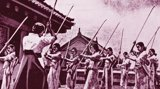
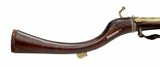
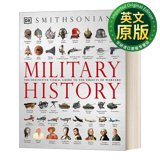
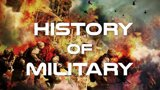
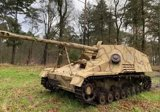
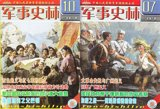
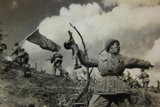
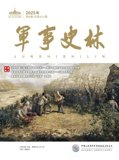
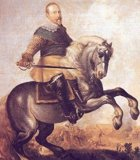
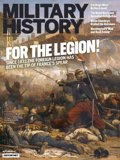
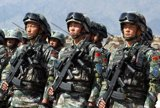
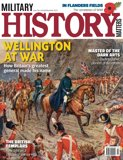
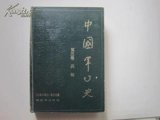
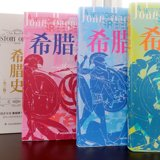
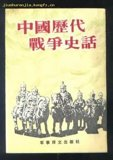
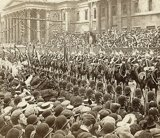
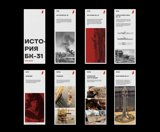
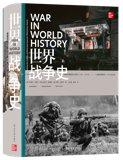
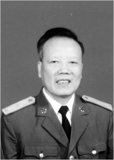
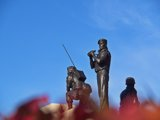
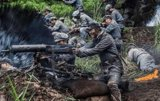
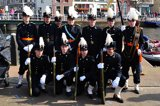
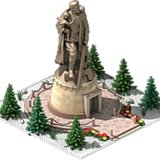
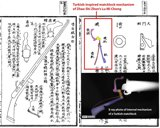
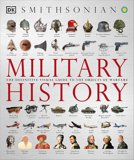
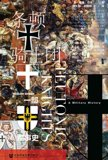
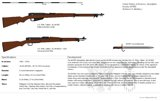
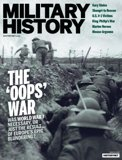
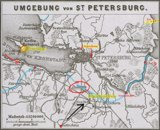
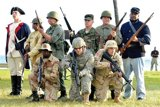
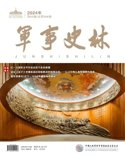
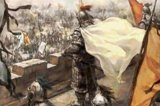
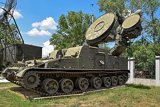


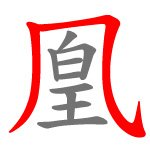
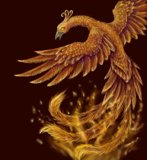
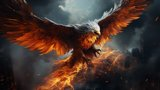
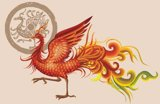
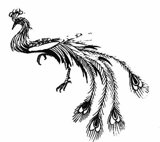
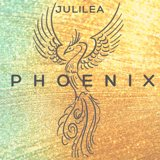
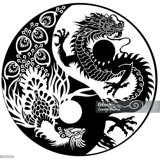
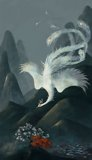
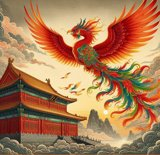
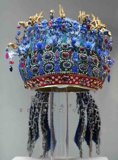
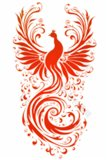
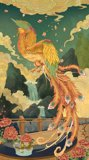
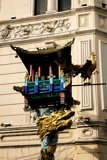
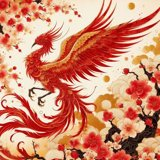
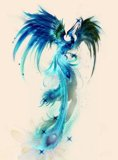
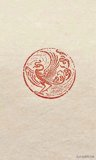
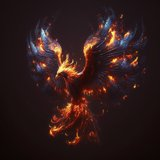
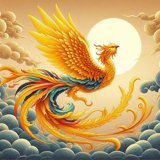
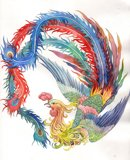
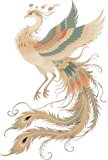
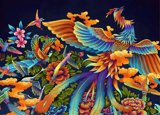
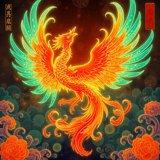
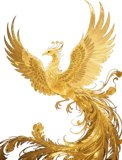
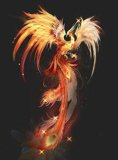
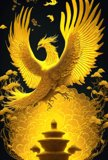
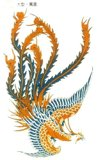
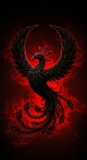
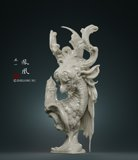
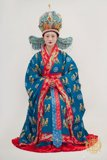
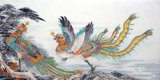
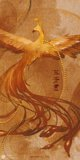
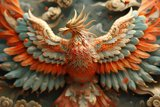
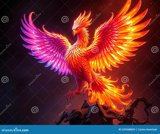
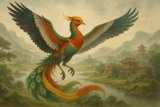
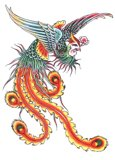
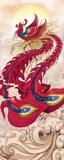
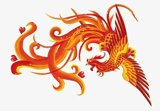
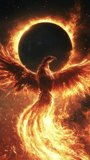
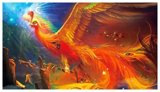
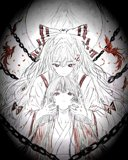
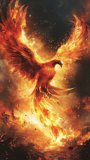
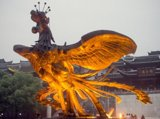
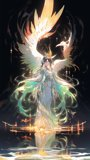
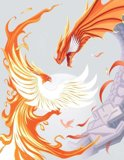
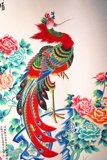
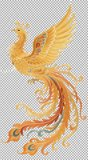
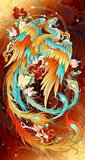
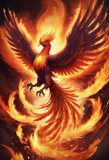
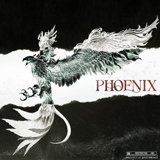
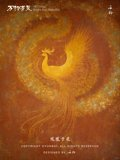
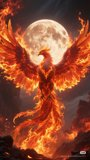
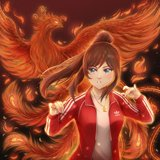
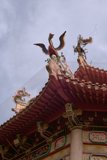
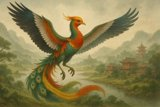
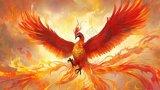
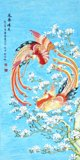
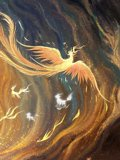
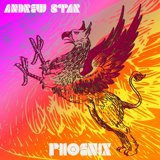
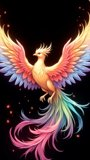
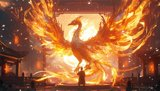
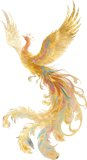
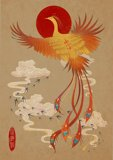
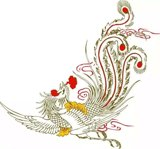
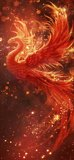
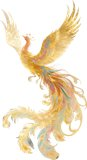
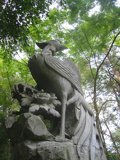
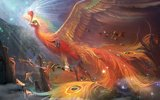
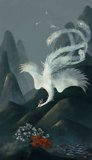
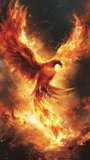
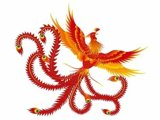
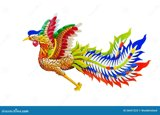
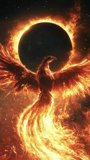
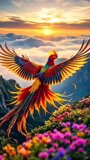
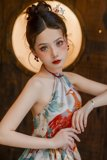
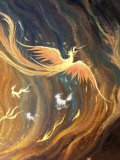
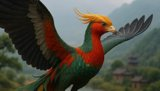
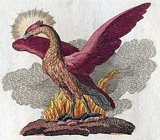
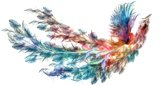
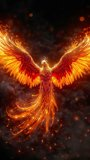
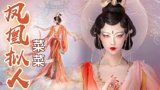
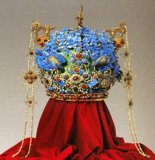
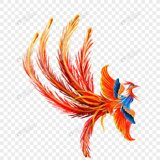
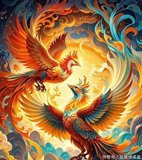
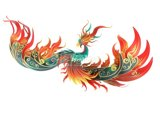
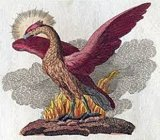
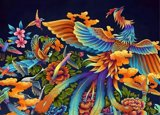
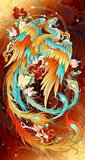
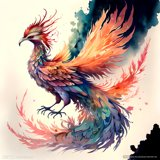
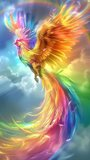
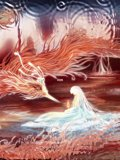
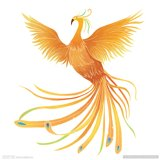
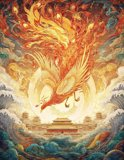
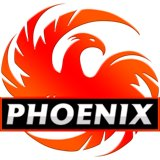
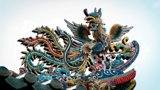
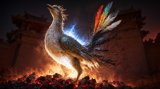
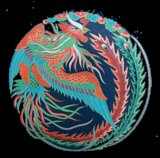
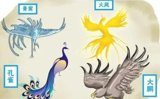
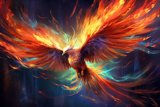
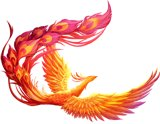
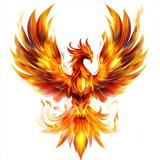


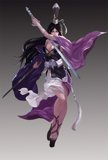
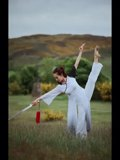
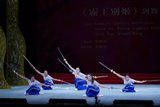
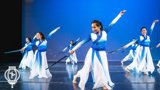
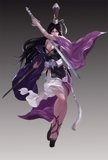
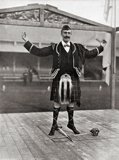
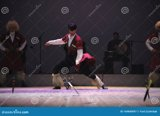
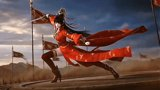
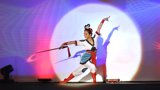
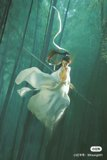
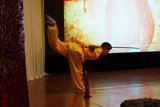
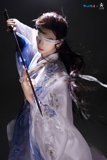
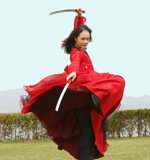
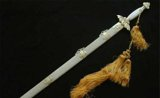
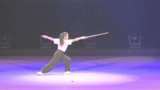
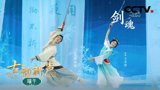
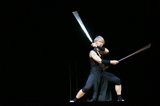
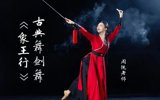
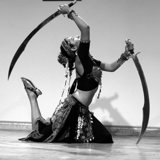
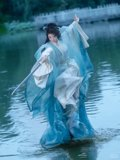
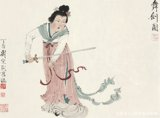


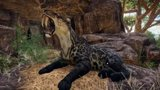
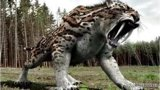
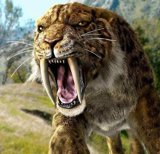
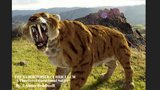
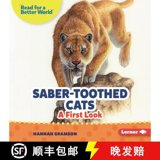
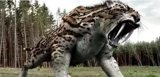
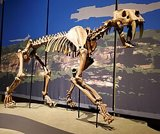
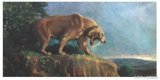
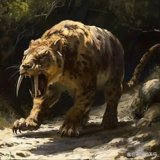
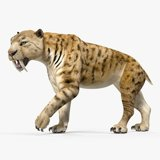
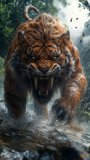
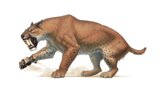
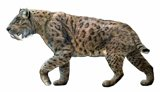
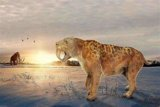
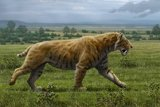
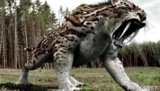
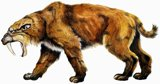
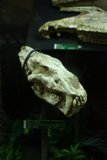
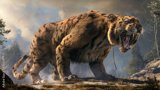
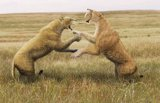
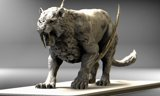
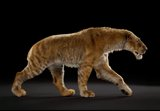
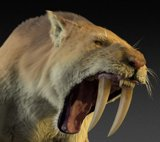
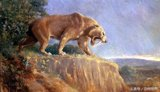
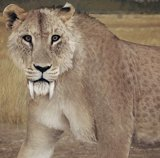
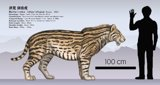
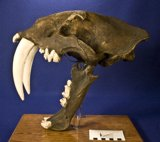
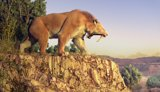
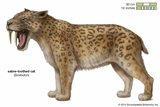
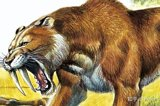
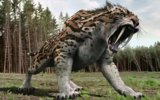
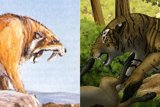
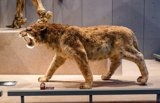
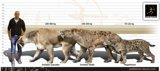
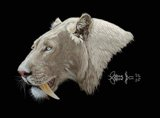
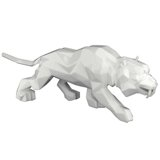
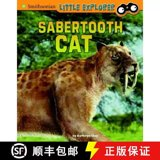
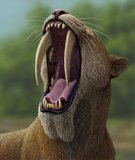
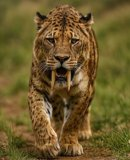
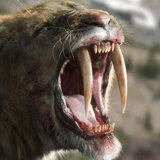
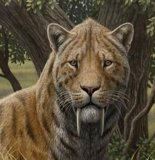
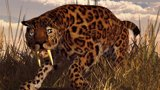
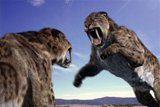
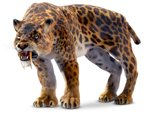
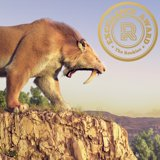
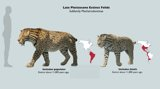
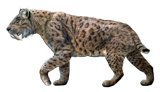
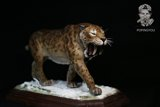
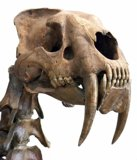
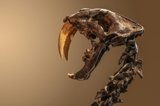
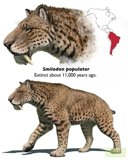
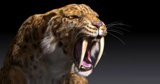
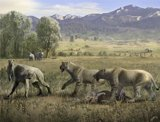
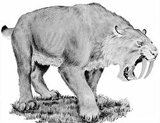
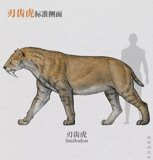
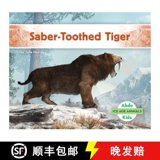
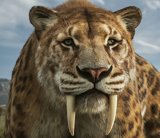
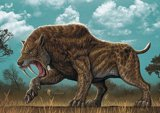
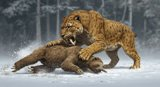
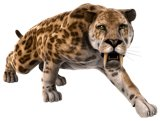
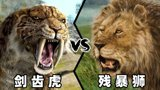
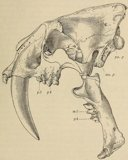
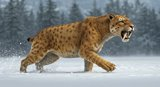
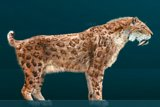
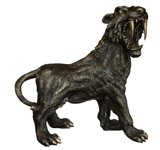
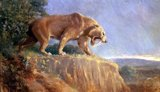
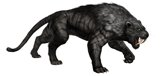
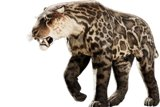
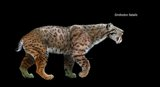
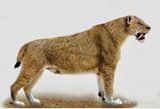
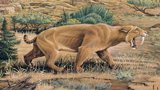
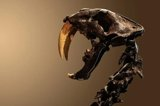
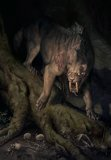
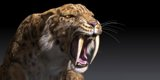
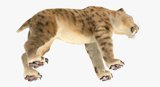
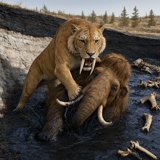
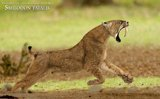
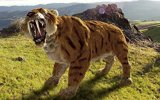
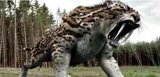
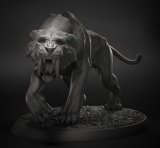
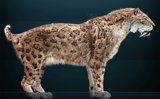
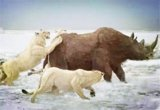
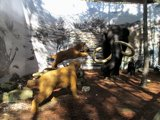
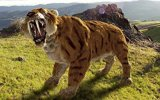
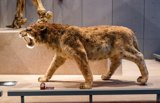
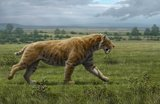
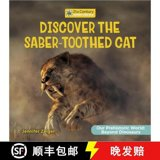
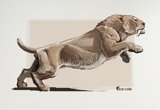
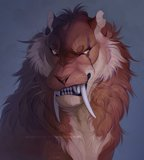
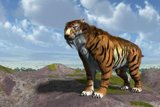
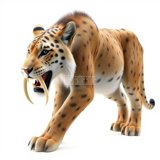
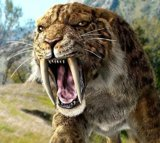
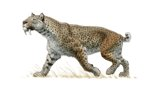
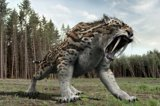
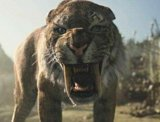
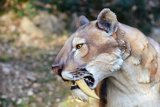
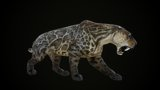
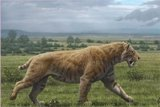
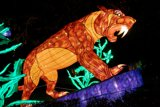
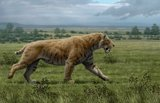


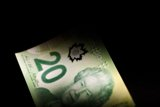
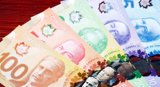
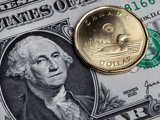
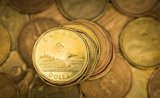
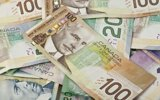
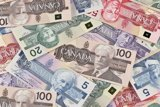
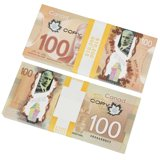
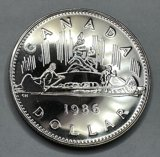
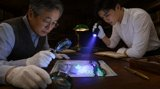
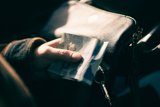
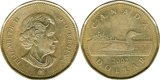
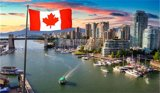
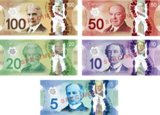
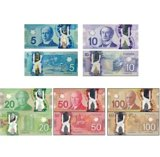
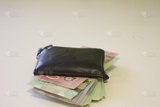
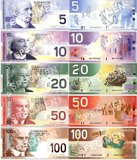
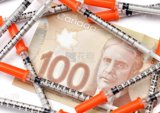
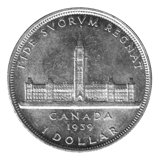
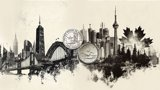
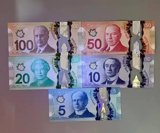
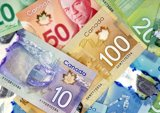
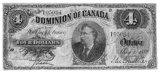
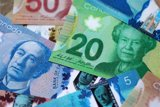
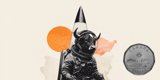
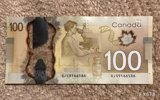
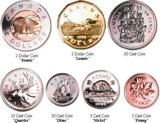


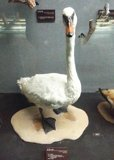
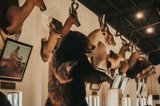
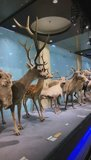
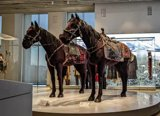
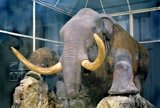
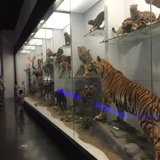
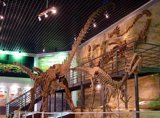
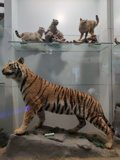
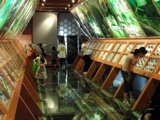
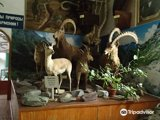
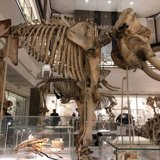
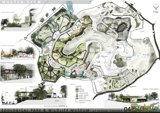
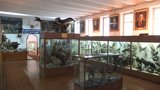
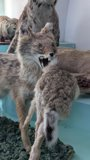
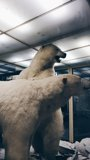
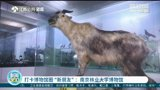
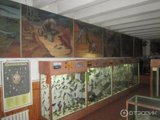
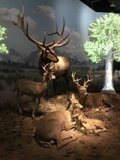
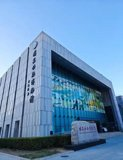
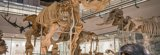
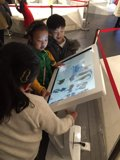
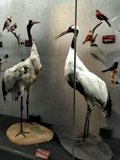
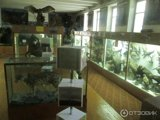
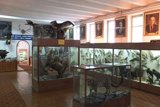
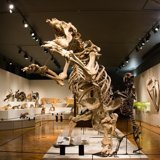
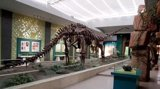
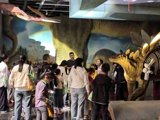
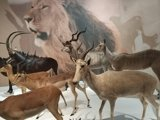
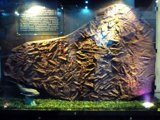
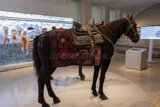
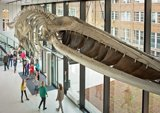
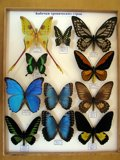
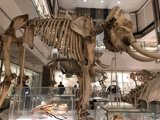
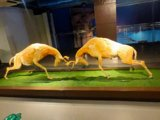
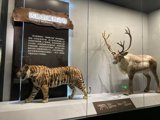
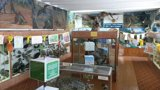
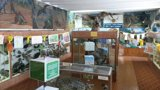
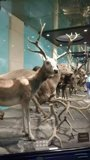
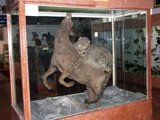
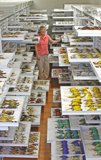
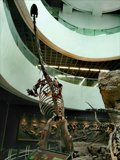
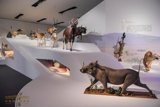
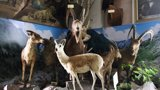
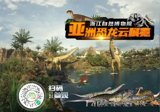
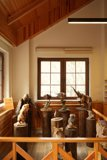
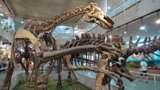
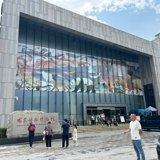
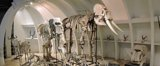
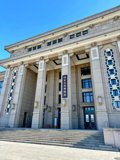
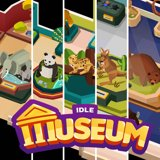
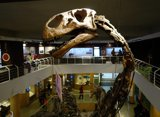
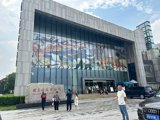
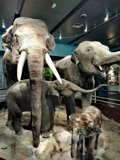
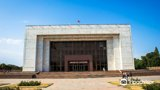
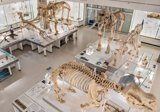
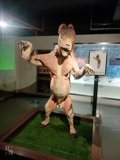
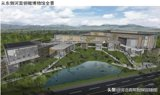
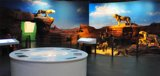
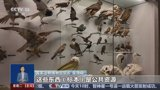
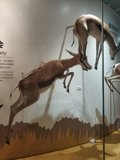
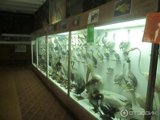
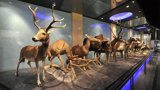
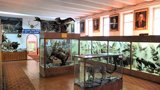
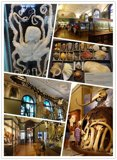
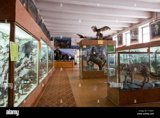
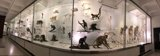
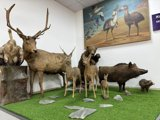
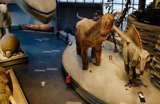
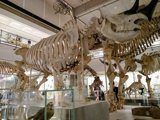
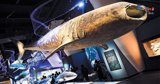
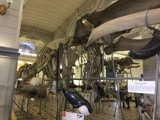
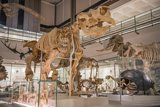
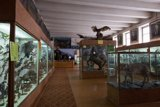
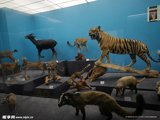
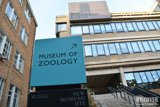
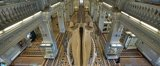
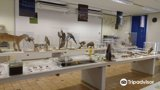
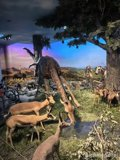
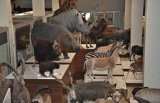
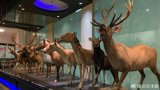
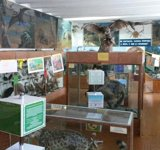
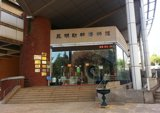
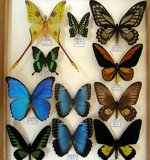
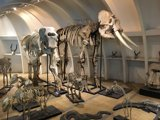
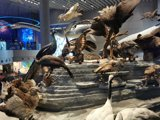
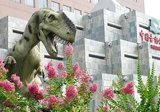
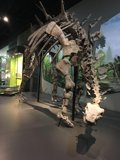
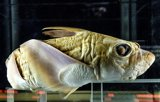
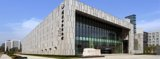
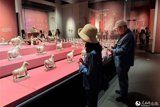
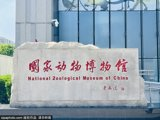


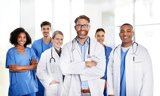
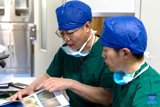
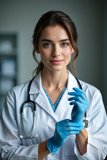
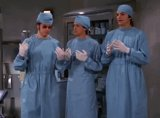
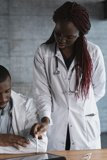
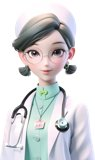
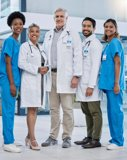
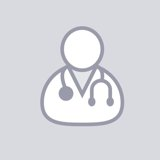
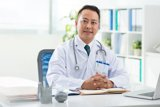
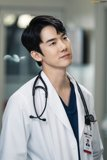
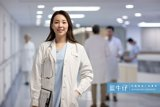
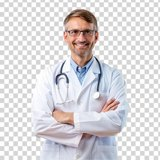
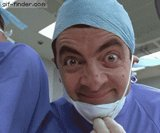
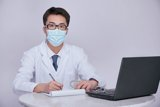
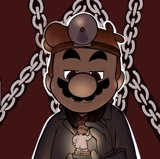
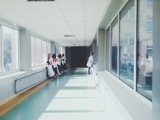
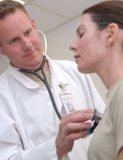
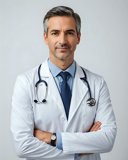
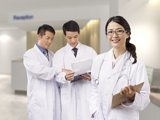
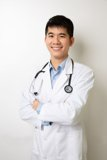
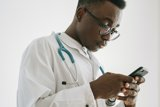
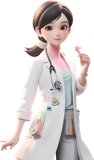
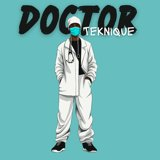
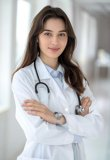
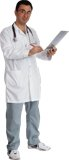
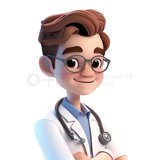
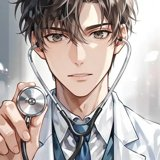
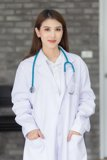
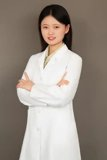
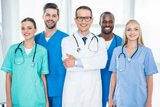
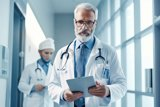
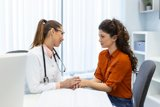
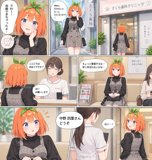
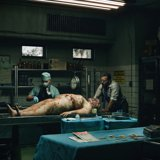
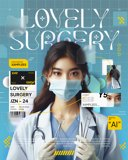
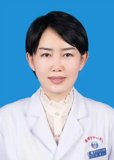
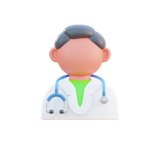
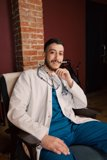
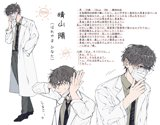
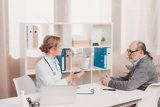
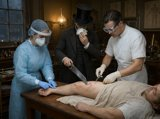
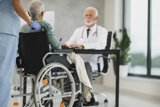
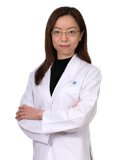
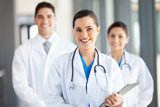
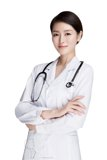
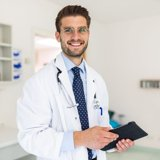
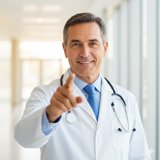
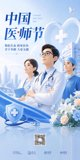
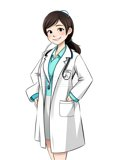
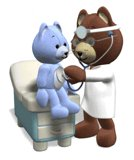
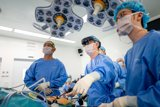
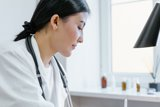
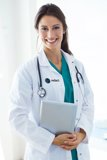
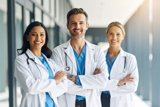
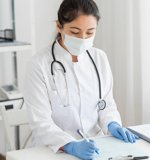


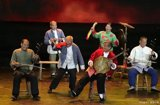
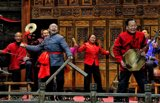
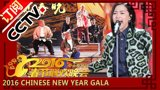
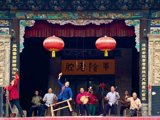
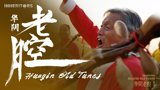
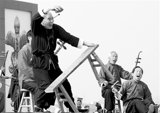
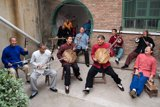
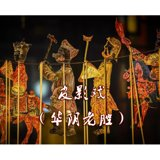
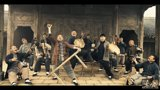
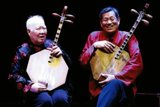
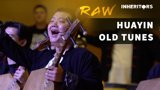
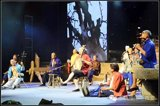
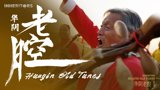
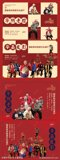
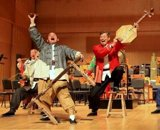
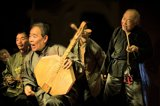


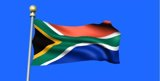
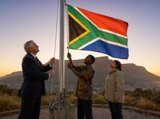
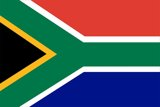
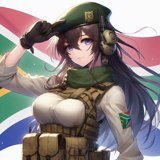
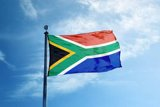
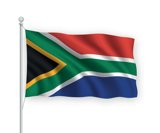
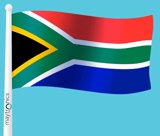
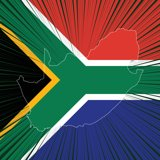
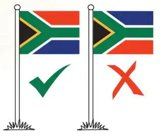
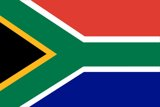
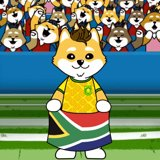
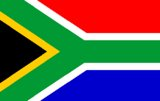
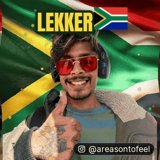
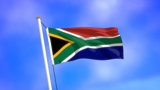
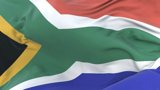
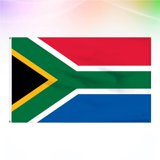
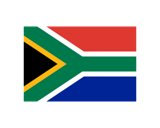
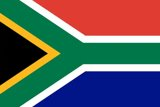
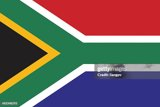
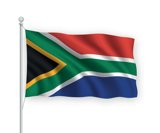
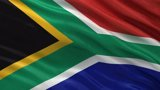
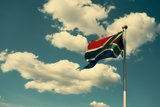
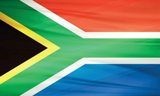
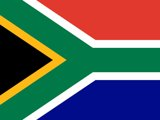
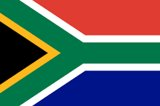
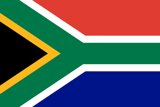
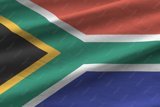
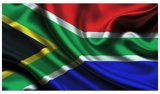
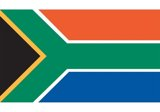
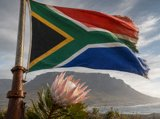
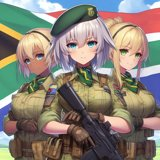


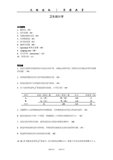
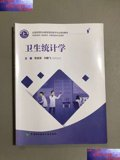
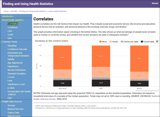
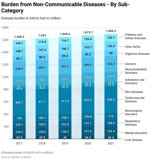
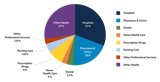
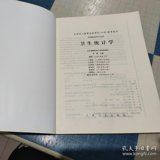
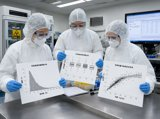
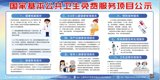
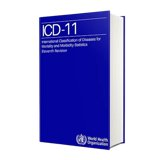
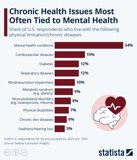
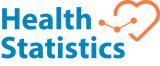
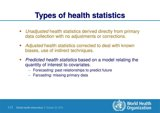
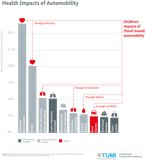
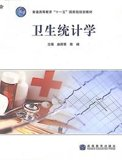
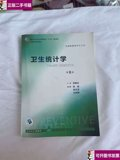
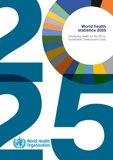
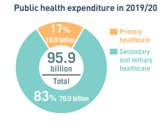
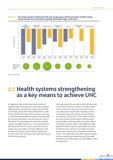
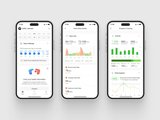
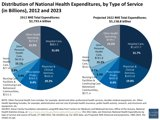
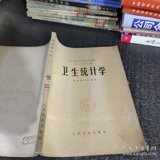
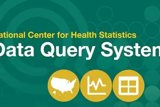


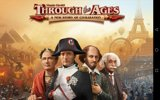
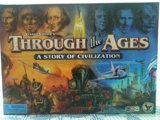
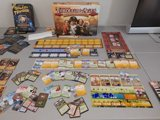
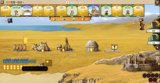
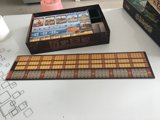
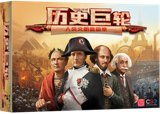
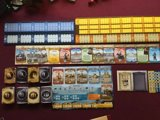
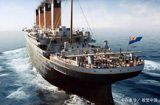


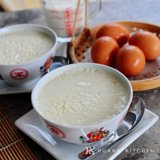
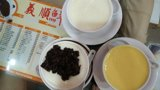
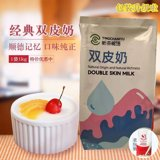
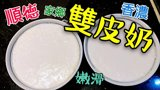
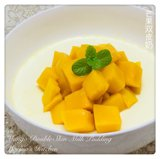
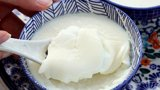
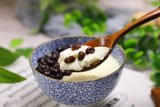
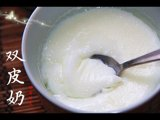
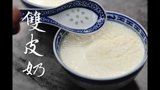
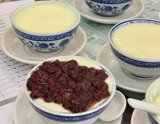
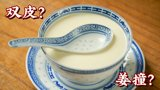
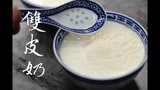
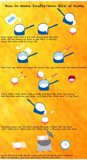
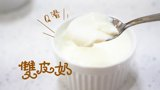
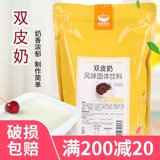
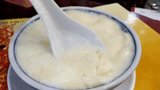
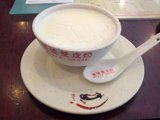


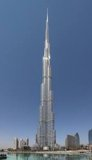
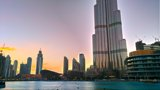
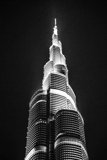
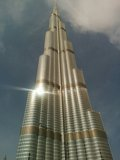
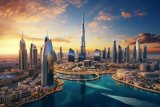
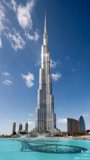
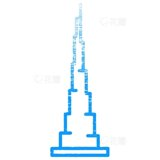
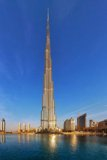
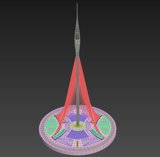
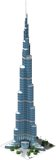
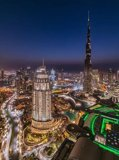
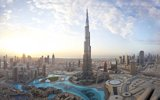
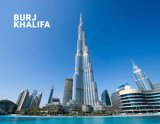
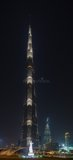
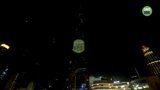
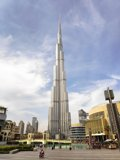
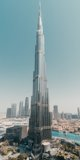
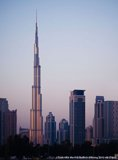
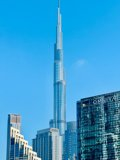
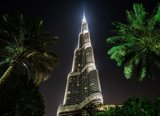
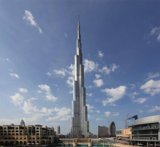
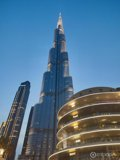
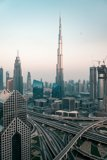
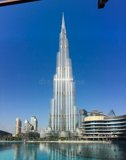
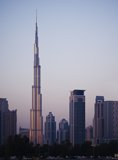
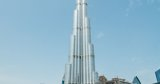
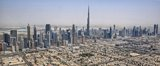
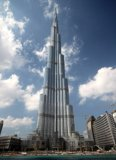
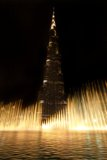
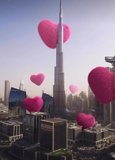
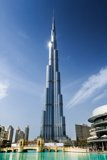
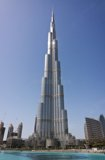
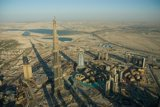
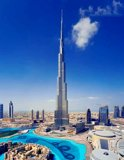
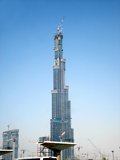
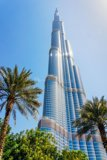
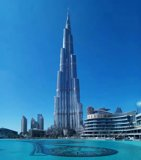
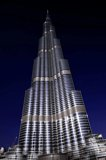
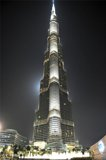
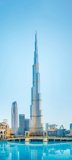
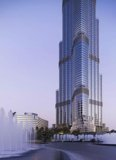
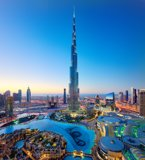
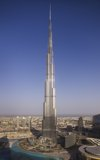
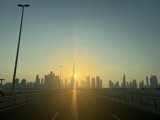
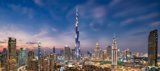
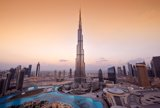
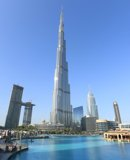
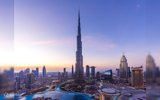
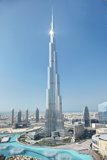
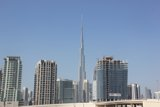
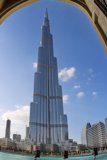
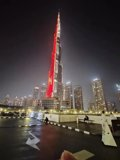
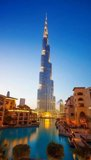
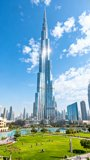
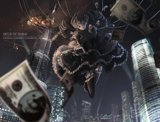
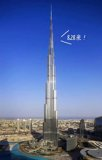
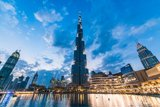
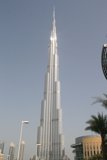
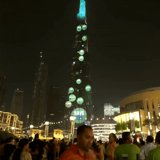
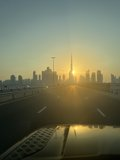
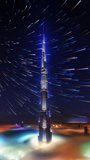
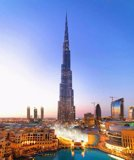
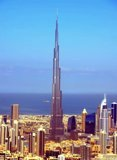
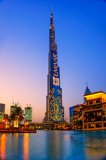
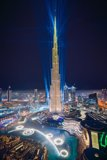
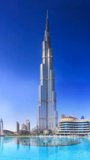
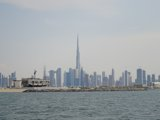
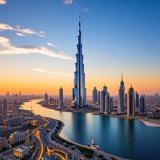
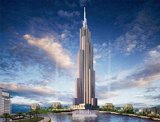
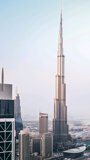
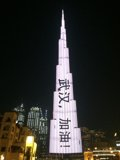
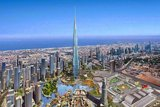
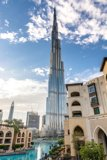
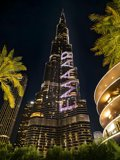
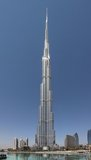
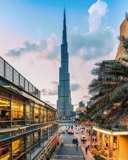
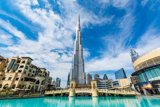
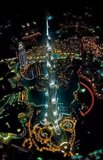
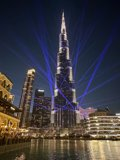
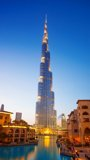
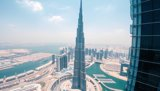
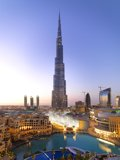
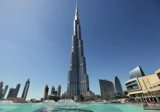
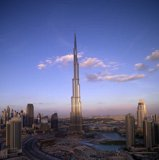
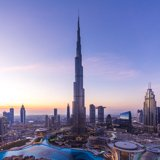
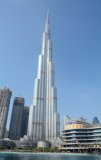
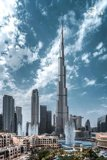
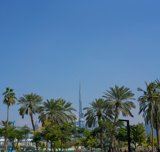
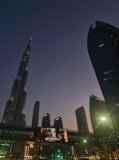


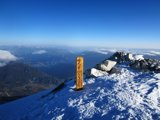
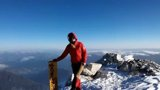
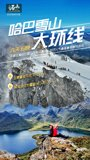
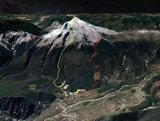
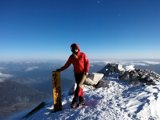
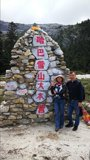
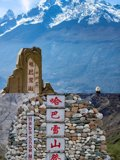
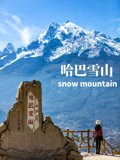
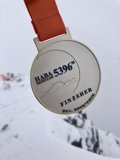
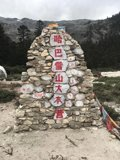


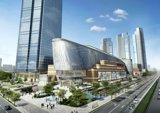
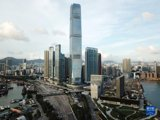
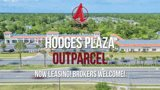
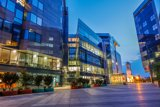
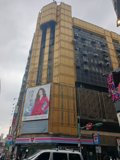
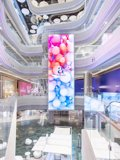
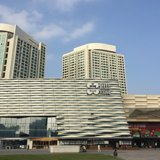
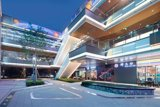
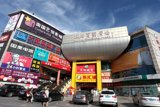
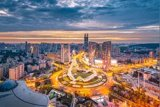
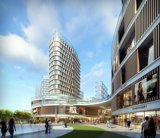
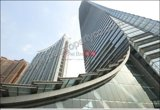
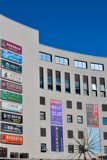
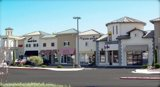
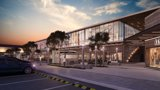
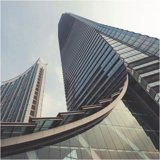
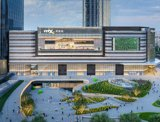
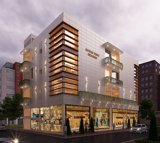
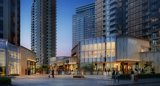
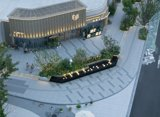
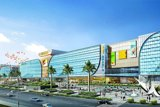
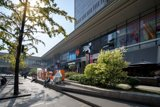
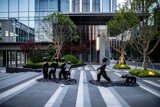
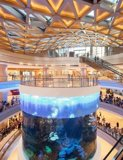
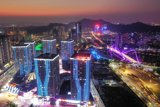
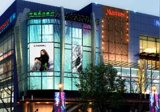
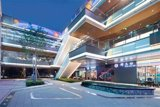
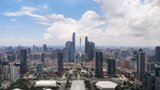
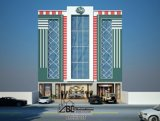
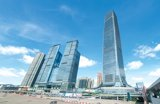
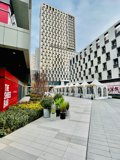
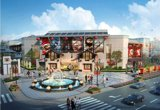
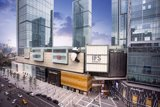
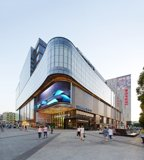
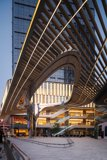
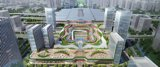
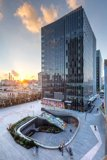
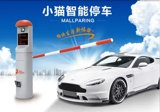
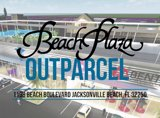
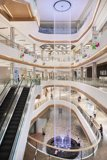
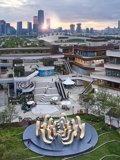
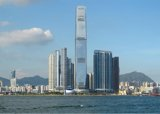
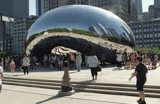
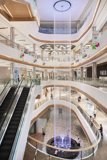
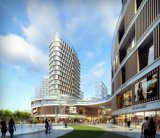
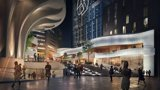
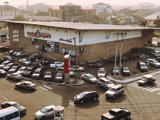
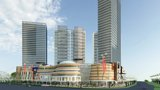
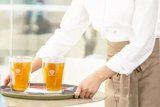
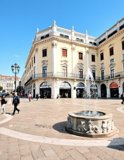


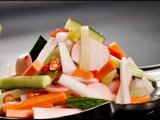
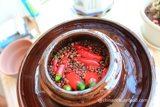
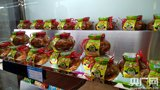
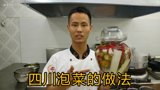
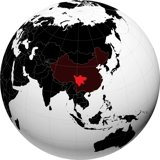
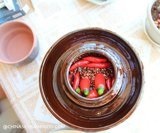
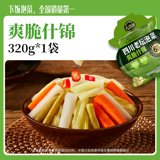
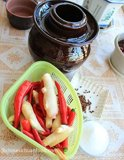
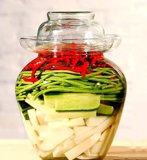
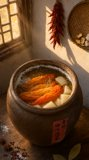
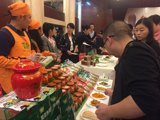
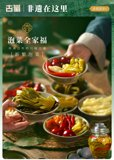
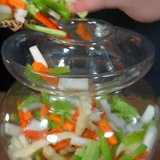
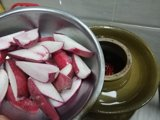
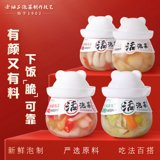
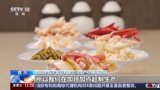
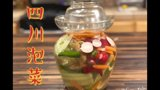
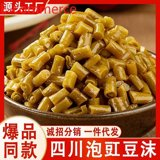
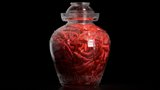
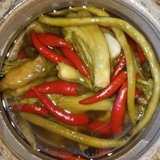
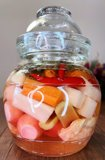
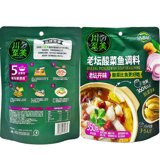
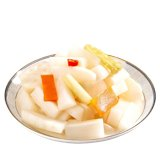
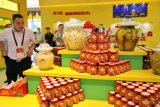


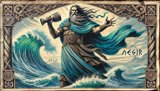
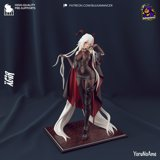
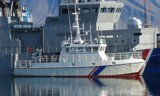
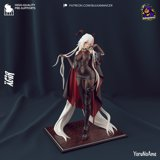


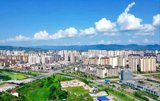
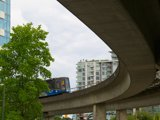
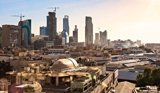
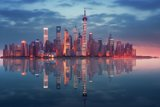
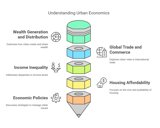
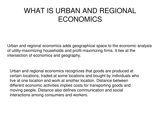
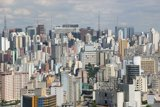
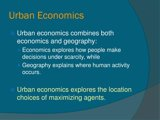
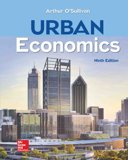
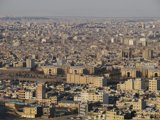
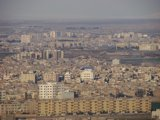
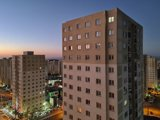
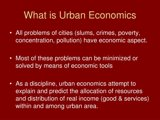
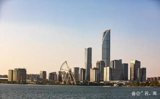
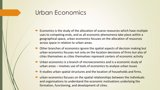
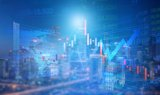
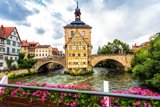
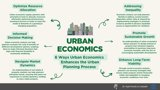
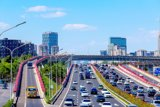
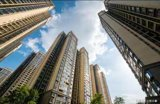


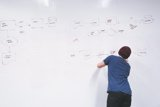
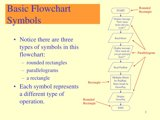
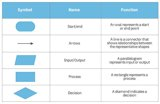
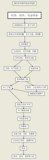
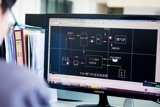
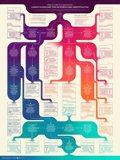
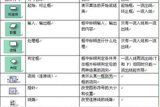
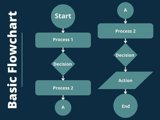
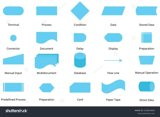
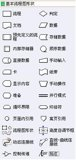
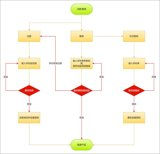
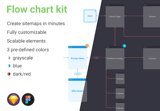
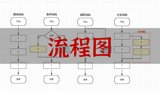
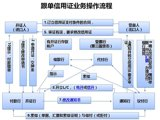
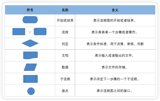
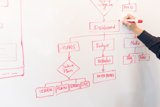
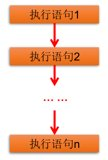
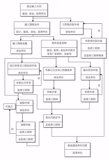
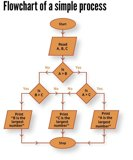
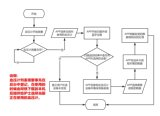
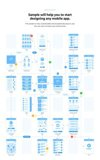
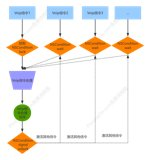
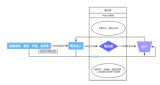
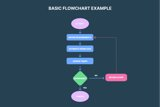
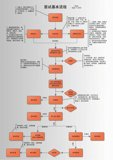
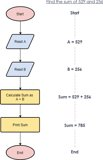
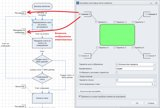
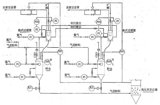
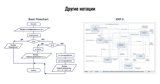
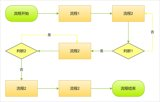

SyntaxError: not a TIFF file (header b'\x00\x00\x0b\x00\x0f\x01\x02\x00' not valid) (<string>)

In [ ]:
# prepare 结果：按概念分批查看；每个概念先文档、后图片，概念和图片编号均从 1 开始。
from pathlib import Path
from html import escape
from io import BytesIO
from base64 import b64encode
from PIL import Image, ImageOps
from IPython.display import HTML, display
import lance

PROJECT = Path("/yzp/zhaozy/yangzepeng/0905/demiwtg")
import sys
sys.path.insert(0, str(PROJECT)) if str(PROJECT) not in sys.path else None
from demiflow.lance.assets import BlobAssetReader, AssetError

TABLE_URI = PROJECT / "preparation/datasets/articles.lance"
VERSION = 4
IMAGE_TABLE_URI = PROJECT / "preparation/datasets/images.lance"
IMAGE_VERSION = 5
BLOB_TABLE_URI = PROJECT / "collect/datasets/images.lance"  # 原图字节与分辨率
BLOB_VERSION = 5
CONCEPT_RANGE = "1-50"  # 按概念名排序，含首尾编号；下一批改为 "11-20"；空字符串显示全部
IMAGE_RANGE = "1-100"  # 每个概念内的图片范围，含首尾；空字符串显示该概念全部图片
THUMB_SIZE = 160

# preparation 正式运行：源表版本和目标表分别配置；取消注释才执行。
from preparation.preparation_pipeline import run_pipeline, default_config
SOURCES = {
    'concepts': {'uri': 'datasets/master_concepts.lance', 'version': 2},
    'documents': {'uri': 'demiwtg/collect/datasets/documents.lance', 'version': 4},
    'images': {'uri': 'demiwtg/collect/datasets/images.lance', 'version': 5},
}
OUTPUT_TABLE_URI = 'demiwtg/preparation/datasets/articles.lance'
WRITE_MODE = 'merge'  # 文章表：'append' 追加行；'overwrite' 覆盖；'merge' 保留原主键合并。
OUTPUT_IMAGE_TABLE_URI = 'demiwtg/preparation/datasets/images.lance'
IMAGE_WRITE_MODE = 'merge'  # 图片表独立配置：'append' / 'overwrite' / 'merge'。
RUN_DIR = PROJECT / 'preparation/datasets/debug_20260925_01'
CONCEPT_IDS = ['legacy:莜面栲栳栳']
# result = run_pipeline(RUN_DIR, PROJECT.parent, ids=CONCEPT_IDS, sources=SOURCES,
#                       through='export', model_config=default_config(),
#                       target_uri=OUTPUT_TABLE_URI, visual_target_uri=OUTPUT_IMAGE_TABLE_URI,
#                       write_mode=WRITE_MODE, visual_write_mode=IMAGE_WRITE_MODE)

# Lance 原生 SQL：每个 dataset.sql() 中 FROM dataset 指当前打开的表。
CONCEPT_WHERE = "TRUE"  # 例如 "concept LIKE '%锅%'"；先过滤概念，再取 CONCEPT_RANGE
ARTICLE_WHERE = "review_status = 'reviewed'"  # 可加 AND article_kind = '...'
IMAGE_WHERE = "width >= 1024 AND height >= 1024"  # 例如 "width >= 512 AND height >= 512"
# width/height 是存储原图的像素尺寸（与下方标注一致），不是缩略图尺寸。
# 其他例子："width > height"；"CAST(width AS BIGINT) * height >= 1000000"；"ext = 'png'"
# 先按 IMAGE_WHERE 过滤，再按 sha256 排序和 IMAGE_RANGE 编号；尺寸 NULL 不通过大小比较。

concept_start, concept_end = map(int, CONCEPT_RANGE.split("-")) if CONCEPT_RANGE.strip() else (1, None)
if concept_start < 1 or (concept_end is not None and concept_end < concept_start):
    raise ValueError('CONCEPT_RANGE 请填写如 "1-10" 的正整数范围，或留空显示全部')
start, end = map(int, IMAGE_RANGE.split("-")) if IMAGE_RANGE.strip() else (1, None)
if start < 1 or (end is not None and end < start):
    raise ValueError('IMAGE_RANGE 请填写如 "1-50" 的正整数范围，或留空显示全部')
articles = lance.dataset(str(TABLE_URI), version=VERSION)
curated_images = lance.dataset(str(IMAGE_TABLE_URI), version=IMAGE_VERSION)
raw_images = lance.dataset(str(BLOB_TABLE_URI), version=BLOB_VERSION)
image_reader = BlobAssetReader(str(BLOB_TABLE_URI), id_column="sha256", version=BLOB_VERSION, verify=True)

# 概念目录：文档与全部已发布图片的并集；图片尺寸过滤不改变概念编号。
article_concepts = articles.sql(f"""
    SELECT DISTINCT concept FROM dataset
    WHERE ({ARTICLE_WHERE}) AND ({CONCEPT_WHERE}) AND concept IS NOT NULL
""").build()
image_concepts = curated_images.sql(f"""
    SELECT DISTINCT concept
    FROM (SELECT unnest(published_concepts) AS concept FROM dataset)
    WHERE ({CONCEPT_WHERE}) AND concept IS NOT NULL
""").build()
concept_names = {row["concept"] for query in (article_concepts, image_concepts)
                 for batch in query.to_batch_records() for row in batch.to_pylist() if row["concept"]}
concepts = sorted(concept_names)
selected_concepts = concepts[concept_start - 1:concept_end]
concept_shown = f"{concept_start}–{concept_start + len(selected_concepts) - 1}" if selected_concepts else "无"
display(HTML(f'<div style="font-size:12px">概念共 {len(concepts)} 个 · 当前 {concept_shown}</div>'))

for concept_number, concept in enumerate(selected_concepts, concept_start):
    concept_sql = concept.replace("'", "''")
    article_query = articles.sql(f"""
        SELECT article_id, concept, review_status, content, illustrations
        FROM dataset
        WHERE concept = '{concept_sql}' AND ({ARTICLE_WHERE})
        ORDER BY article_id
    """).build()
    rows = [row for batch in article_query.to_batch_records() for row in batch.to_pylist()]
    image_query = curated_images.sql(f"""
        SELECT sha256 FROM dataset
        WHERE array_contains(published_concepts, '{concept_sql}')
    """).build()
    image_shas = {row["sha256"] for batch in image_query.to_batch_records() for row in batch.to_pylist()}
    # 保留文章配图与视觉审核已发布图的并集；所有图片统一接受尺寸过滤。
    for row in rows:
        if row["review_status"] == "reviewed":
            image_shas.update(item["sha256"] for item in (row["illustrations"] or []) if item["sha256"])
    images = []
    if image_shas:
        image_ids = ", ".join("'" + sha.replace("'", "''") + "'" for sha in sorted(image_shas))
        image_query = raw_images.sql(f"""
            SELECT sha256, width, height, ext, byte_size
            FROM (
                SELECT sha256, resolution.stored_width AS width,
                       resolution.stored_height AS height, ext, byte_size
                FROM dataset
                WHERE sha256 IN ({image_ids})
            )
            WHERE ({IMAGE_WHERE})
            ORDER BY sha256
        """).build()
        images = [row for batch in image_query.to_batch_records() for row in batch.to_pylist()]
    selected = images[start - 1:end]

    parts = [f'<div style="font-size:14px;line-height:1.5;max-width:1100px">'
             f'<b>{concept_number}. {escape(concept)}</b>']
    for row in rows:
        for topic in (row["content"] or []):
            if topic.get("title"):
                parts.append(f'<div style="margin-top:8px"><b>{escape(topic["title"])}</b></div>')
            for paragraph in topic["content"]["paragraphs"]:
                parts.append(f'<p style="margin:3px 0;white-space:pre-wrap">{escape(paragraph)}</p>')
    shown_range = f"{start}–{start + len(selected) - 1}" if selected else "无"
    parts.append(f'<div style="margin-top:8px"><b>已发布图片 · 筛选后 {len(images)} / 共 {len(image_shas)} 张 · 当前 {shown_range}</b></div>')
    parts.append('<div style="display:flex;flex-wrap:wrap;gap:6px;margin-top:4px">')
    for number, item in enumerate(selected, start):
        sha = item["sha256"]
        try:
            raw = image_reader.read_bytes(sha)
            with Image.open(BytesIO(raw)) as source:
                width, height = source.size  # 原始图片像素尺寸，不是缩略图尺寸
                try:
                    oriented = ImageOps.exif_transpose(source)
                except (SyntaxError, OSError, ValueError):
                    oriented = source  # EXIF 损坏：按原始方向显示
                thumb = oriented.convert("RGBA")
                thumb.thumbnail((THUMB_SIZE, THUMB_SIZE))
                canvas = Image.new("RGBA", thumb.size, "white")
                canvas.alpha_composite(thumb)
                buffer = BytesIO()
                canvas.convert("RGB").save(buffer, format="JPEG", quality=85)
            url = "data:image/jpeg;base64," + b64encode(buffer.getvalue()).decode()
            picture = f'<img src="{url}" alt="图 {number}" style="max-width:100%;max-height:100%">'
            label = f"{number} · {width} × {height}"
        except (AssetError, OSError, ValueError, SyntaxError) as error:
            picture = f'<span title="{escape(str(error))}">图片读取失败</span>'
            label = f"{number} · 分辨率未知"
        parts.append(
            f'<figure title="{sha}" style="margin:0;width:{THUMB_SIZE}px;text-align:center">'
            f'<div style="height:{THUMB_SIZE}px;display:flex;align-items:center;justify-content:center">'
            f'{picture}</div><figcaption style="font-size:11px">{label}</figcaption></figure>'
        )
    parts.append('</div></div>')
    display(HTML("".join(parts)))
